# Neural Networks - Regularisation

## 1. Generalisation: The Problem We Actually Care About

- **Empirical risk** = average training loss: expected prediction error. Goal is to minimise risk -> better performance on unseen data.

$$
\hat{R}(\theta) = \frac{1}{N}\sum_{i=1}^N l(f_{\theta}(x_i),y_i)
$$

- **Population risk** or **True risk**: if $(x, y) ~ p_{\text{data}}$ generated from unknown distribution, what loss should we expect:

$$
R(\theta) = \mathbb{E}_{(x,y)~p_{\text{data}}}[l(f_{\theta}(x), y)]
$$

- Since we don't know $p_{text{data}}$, we minimise empirical risk and hope:

$$
\hat{R}(\theta) \approx R(\theta)
$$

### What is Generalisation Gap?

$$
\text{generalisation gap } = R(\theta) - \hat{R}(\theta) \approx L_{\text{validation}} - L_{\text{training}}
$$

- If $L_{\text{validation}}$ is very high while $L_{text{training}}$ is very low -> **overfitting**.

### Underfitting, Good Fitting and Overfitting

- **Underfitting**: high $L_{\text{train}}$, high $L_{text{validation}}$
- **Good fitting**: low $L_{\text{train}}$, similarily low $L_{text{validation}}$
- **Underfitting**: very low $L_{\text{train}}$, much higher $L_{text{validation}}$

### What gets memorised during training?

- A model has good generalisation if it captures signal while ignoring noise.

$$
\text{observed data } = \text{ signal } + \text{ noise}
$$

### Why training loss is optimistic?

- Model is biased toward train set -> overly optimistic estimate future performance.

### Train, validation and test sets

- **Train set**: Optimise params: $\theta \leftarrow \theta - \eta\nabla_{\theta}L_{\text{train}}$
- **Validation set**: used to decide on model hyperparams.
- **Test set**: final unbiased evaluation, how well does the model perform on unseen data.
- Example split: 70% train, 15% validation, 5% test

### Why validation data can also be overfitted?

- Repeated validation tuning -> validation overfitting, aka **data leakage** or **selection bias**.
- **Nested cross-validation**:
  - inner loop: hyperparam tuning
  - outer loop: evaluate final generalisation error on unseen data

### Data leakage

- Use validation set to learn -> overfit already known data.
- Standardisation:

$$
x' = \frac{x - \mu}{\sigma}
$$

- Applied **only on train set**
- Feature engineering
- Cross validation
- Data augmentation

### Independent and Identically distributed (i.i.d) data

- Assumptions about data:
  - I: each point is a separate event
  - i.d.: all points have the same rules (distribution)
- **Distribution shift**: statistical properties change in different stages of pipeline -> break the *Identically distributed* assumption.
  - **Covariate shift**: different inputs in training and real world, but relationship between inputs and outputs remain. (e.g., train driving car in sunny, actual drive in foggy -> same output slow down.)
  - **Label shift**: Inputs look the same, but what they mean different. $P(y|x)$ changes. (e.g., predict spam emails by word "free money", but years later, they use different words -> definition of "spam" shifts relative to those words.)
  - **Concept shift**: both inputs and their meaning change. (e.g., house price predicted by # bedrooms. But sometimes, a bedroom worths more than a living room -> relationship feature and price is broken.)

> Imagine you are learning to ride a bike in your backyard.
>
> *  **No Shift (i.i.d.):** You practice on flat grass. Your brain learns: "Pedal hard + lean forward = move." This works perfectly because the ground is always flat and green.
> * **Distribution Shift:** Now you take that bike to a beach.
>   * The sand feels different than the grass (Covariate Shift). Even though your brain knows how to balance, the physics of moving on sand are different from grass. Your old rules no longer predict the outcome correctly.
>   * Or, imagine you learned to ride only in summer. Suddenly it's winter, and there is snow. The bike looks the same ($x$), but riding on ice requires completely different physics than riding on dry ground. The "rulebook" of how the world works has changed.

### Interpolation

- **Interpolation**: model fits every training example: $l(f_{\theta}(x_i), y_i) = 0$ for all i. New data points fall in train data distribution.
- The opposite is **Extrapolation**.
- Interpolation is generally good for generalisation. It learned rules applied to **unseen but familiar data**.
- **Wiggle problem**: overfitting to noise training data -> bad performance, especially in complex neural networks.
- Interpolation to **Bias-Variance tradeoff**:
  - **Underfitting** (high bias): miss complex patterns
  - **Overfitting** (high variance): complax models capture noise
  - **Just right**: regularised models learn trend in interpolation region.
- Interpolation is generally safer than extrapolation because the predicted point is in known range.

### What is Regularisation?

- Core problem: **Overfitting** if only minimise empirical risk.
- Add more term in the min function

$$
\min_{\theta}[\hat{R}(\theta) + \lambda\Omega(\theta)]
$$

$$ \text{Loss} = \underbrace{\text{Empirical Risk}}_{\text{Accuracy on Data}} + \underbrace{\lambda \cdot \Omega(\theta)}_{\text{Penalty for Complexity}} $$

- **$\Omega(\theta)$ (Complexity Penalty):** How complex the model is based on params = # weights.
- **$\lambda$**: Knob decides how much you care about complexity vs accuracy:
  - High $\lambda$: Care more about complexity
  - Low $\lambda$: Care more about accuracy
- If only minimise $\Omega$: **Underfitting**

> Learning is finding patterns in reality, which contains both **Signal** and **Noise**.

- Regularisation types:
  - L2 Regularisation (Ridge): squared weights
  - L1 Regularisation (Lasso): absolute weights

### Central tension

- What cause the tension of overfitting and generalisation:
  - Data noise -> learn noise
  - Limited train data
  - Model complexity: complex models overfit (high variance), simpler models underfit (high bias).

Degree  1 | train loss: 0.2930 | validation loss: 0.1693


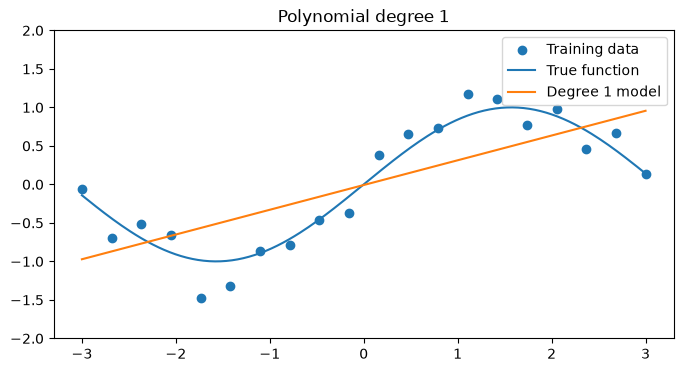

Degree  5 | train loss: 0.0367 | validation loss: 0.0087


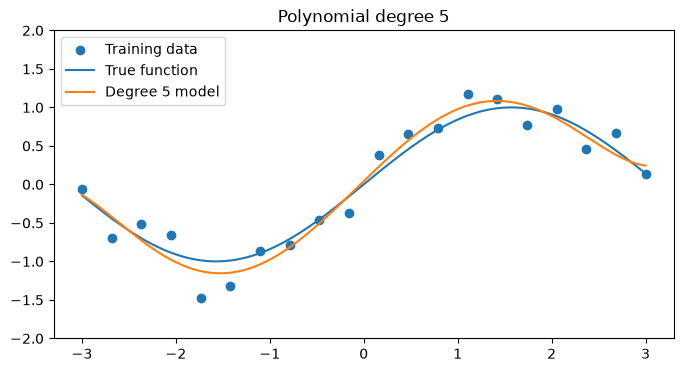

Degree 15 | train loss: 0.0043 | validation loss: 0.5396


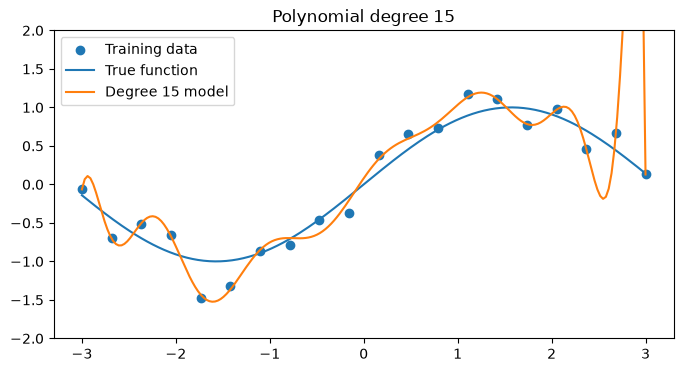

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

X_train = np.linspace(-3, 3, 20)
y_train = np.sin(X_train) + .25*rng.normal(size=len(X_train))

X_val = np.linspace(-3, 3, 200)
y_val = np.sin(X_val)

degrees = [1, 5, 15]

for degree in degrees:
    coefficients = np.polyfit(X_train, y_train, degree)
    model = np.poly1d(coefficients)

    train_predictions = model(X_train)
    val_predictions = model(X_val)

    train_loss = np.mean((train_predictions - y_train)**2)
    val_loss = np.mean((val_predictions - y_val)**2)

    print(
        f"Degree {degree:2d} | "
        f"train loss: {train_loss:.4f} | "
        f"validation loss: {val_loss:.4f}"
    )

    plt.figure(figsize=(8, 4))
    plt.scatter(X_train, y_train, label="Training data")
    plt.plot(X_val, y_val, label="True function")
    plt.plot(X_val, val_predictions, label=f"Degree {degree} model")
    plt.ylim(-2, 2)
    plt.legend()
    plt.title(f"Polynomial degree {degree}")
    plt.show()

- Degree = 1 -> Underfit
- Degree = 5 -> Good fit
- Degree = 15 -> Overfit

## 2. Bias–Variance Tradeoff

$$
y = f^*(x) + \epsilon
$$

- What we want:
  - $\mathbb{E}[\epsilon | x] = 0$
  - $\text{Var}(\epsilon | x) = \sigma^2$
- $\hat{f}_D(x)$: remember $D$ matters because each train dataset provide different distribution.
- High bias: memorise narrowly one book -> underfit
- High variance: study different materials wildly -> overfit

### Sources of prediction errors

Squared prediction error:

$$
\mathbb{E}_{D,\epsilon}[(y - \hat{f}_D(x))^2] = \mathbb{E}_{D,\epsilon}[(f^*(x) + \epsilon - \hat{f}_D(x))^2]
$$

For average prediction: $\overline{f}(x) = \mathbb{E}_D[\hat{f}_D(x)]$, then:

$$
f^* + \epsilon - \hat{f}_D = \underbrace{f^* - \overline{f}}_{\text{systematic error}} + \underbrace{\overline{f} - \hat{f}_D}_{\text{dataset semsotovotu}} + \underbrace{\epsilon}_{\text{noise}}
$$

Expand the squared term:

$$
\begin{aligned}
\mathbb{E}\left[(y - \hat{f}(x))^2\right] &= \mathbb{E}\left[y^2 - 2y\hat{f}(x) + \hat{f}(x)^2\right] \\
&= \mathbb{E}[y^2] - 2\mathbb{E}[y]\mathbb{E}[\hat{f}(x)] +
\mathbb{E}[\hat{f}(x)^2]
\end{aligned}
$$

Substitude $y = f(x) + \epsilon$:

$$
\begin{aligned}
&= \mathbb{E}[f(x)^2 + 2f(x)\epsilon + \epsilon^2] - 2f(x)\mathbb{E}[\hat{f}(x)] + \mathbb{E}[\hat{f}(x)^2] \\
&= f(x)^2 + \sigma^2 - 2f(x)\mathbb{E}[\hat{f}(x)] + \mathbb{E}[\hat{f}(x)^2]
\end{aligned}
$$

Add and substract $f^2(x)$:

$$
\begin{aligned}
&= f(x)^2 - 2f(x)\mathbb{E}[\hat{f}(x)] + \mathbb{E}[\hat{f}(x)^2] + \sigma^2 \\
&= \left(\mathbb{E}[\hat{f}(x)] - f(x)\right)^2 + \text{Var}(\hat{f}(x)) + \sigma^2
\end{aligned}
$$

Hence the three components:

$$
\mathbb{E}[(y - \hat{f}_D(x))^2] = \text{Bias}(x)^2 + \text{Variance}(x) + \sigma^2
$$

### Bias

- High Bias means:
  - restrictive model class
  - inadequate features
  - strong regularisation
  - not fit optimisation

### Variance

- High variance means:
  - flexible model
  - small dataset
  - noisy observation
  - weak regularisation
  - unstable learning

### Noise

- The last term $\sigma^2$
- Prediction error >= $\sigma^2$

In [2]:
import numpy as np


def true_function(x):
    return np.sin(2 * np.pi * x)


def sample_dataset(n_samples, noise_std):
    X = np.random.uniform(0.0, 1.0, size=n_samples)
    y = true_function(X) + np.random.normal(
        0.0,
        noise_std,
        size=n_samples
    )
    return X, y


def polynomial_features(X, degree):
    return np.column_stack([
        X ** power
        for power in range(degree + 1)
    ])


def fit_polynomial(X, y, degree):
    Phi = polynomial_features(X, degree)

    # More numerically stable than explicitly computing an inverse.
    weights, *_ = np.linalg.lstsq(Phi, y, rcond=None)
    return weights


def predict_polynomial(X, weights):
    degree = len(weights) - 1
    Phi = polynomial_features(X, degree)
    return Phi @ weights


def estimate_bias_variance(
    degree,
    n_datasets=200,
    n_samples=20,
    noise_std=0.2,
    grid_size=200
):
    X_grid = np.linspace(0.0, 1.0, grid_size)
    y_true = true_function(X_grid)

    predictions = []

    for _ in range(n_datasets):
        X_train, y_train = sample_dataset(
            n_samples=n_samples,
            noise_std=noise_std
        )

        weights = fit_polynomial(
            X_train,
            y_train,
            degree
        )

        predictions.append(
            predict_polynomial(X_grid, weights)
        )

    predictions = np.asarray(predictions)

    mean_prediction = predictions.mean(axis=0)

    bias_squared = np.mean(
        (mean_prediction - y_true) ** 2
    )

    variance = np.mean(
        np.var(predictions, axis=0)
    )

    noise = noise_std ** 2

    expected_error = bias_squared + variance + noise

    return {
        "degree": degree,
        "bias_squared": bias_squared,
        "variance": variance,
        "noise": noise,
        "expected_error": expected_error,
    }

In [3]:
degrees = [0, 1, 3, 5, 9, 15]

results = [
    estimate_bias_variance(degree)
    for degree in degrees
]

for result in results:
    print(result)

{'degree': 0, 'bias_squared': np.float64(0.4975003719141597), 'variance': np.float64(0.027646365778638958), 'noise': 0.04000000000000001, 'expected_error': np.float64(0.5651467376927987)}
{'degree': 1, 'bias_squared': np.float64(0.20030555150351653), 'variance': np.float64(0.029701588373585386), 'noise': 0.04000000000000001, 'expected_error': np.float64(0.2700071398771019)}
{'degree': 3, 'bias_squared': np.float64(0.0054634618756993335), 'variance': np.float64(0.016332482045949514), 'noise': 0.04000000000000001, 'expected_error': np.float64(0.061795943921648853)}
{'degree': 5, 'bias_squared': np.float64(0.0005293752546904826), 'variance': np.float64(0.2110498088376227), 'noise': 0.04000000000000001, 'expected_error': np.float64(0.25157918409231317)}
{'degree': 9, 'bias_squared': np.float64(12.624858565762674), 'variance': np.float64(2270.943653482226), 'noise': 0.04000000000000001, 'expected_error': np.float64(2283.608512047989)}
{'degree': 15, 'bias_squared': np.float64(2824544229.501

## 3. Capacity and Memorisation

- **Model capacity**: Degrees of freedom, defines how many independent choices a function makes to map inputs to outputs.
- **Memorisation**: memorise noise due to too much capacity

## 4. L2 Regularisation (Ridge - Weight Decay)

For $\Omega(\theta) = \frac{1}{2}\|\theta\|_2^2$.

$$
\mathcal{L}(\theta) = \mathcal{L}_{\text{data}}(\theta) + \frac{\lambda}{2}\|\theta\|_2^2 = \mathcal{L}_{\text{data}} - \frac{\lambda}{2}\sum_l \|W^{(l)}\|_F^2
$$

- **Square**: makes constraint bounces around zero, no weight is too dominant.
- Use L2 when **all features matter slightly**.

### What happens during gradient descent?

$$
\frac{\partial}{\partial W}(\frac{\lambda}{2}\|W\|_F^2) = \lambda W
$$

Therefore"

$$
\nabla_W \mathcal{L} = \nabla_W\mathcal{L}_{\text{data}} + \lambda W
$$

Then updated weight:

$$
W_{t+1} = W_t - \eta (\nabla_W\mathcal{L} + \lambda W_t) = (1 - \eta\lambda)W_t - \eta\nabla_W\mathcal{L}
$$

> The coefficient $(1 - \eta\lambda)$ is the reason why L2 Regularisation is also called **Weight decay**. It shrinks the weight down to zero.

- Larger weights shrink more.

### Why weight matters?

Suppose: $z = w^Tx + b$.

Cauchy-Schwarz:

$$
\|z\| \le \|w\|_2\|x\|_2
$$

- weights change -> z changes.

### Constrainted form of L2 Regularisation

$$
\mathcal{L} = \mathcal{L}_{\text{data}} + \frac{\lambda}{2}(\|\theta\|_2^2 - c)
$$

for $\|w\|_2^2 \le c$

### Some implementation

In [ ]:
# Regularise loss
def l2_penalty(parameters, reg_lambda):
    penalty = 0.0

    for name, parameter in parameters.items():
        if name.startswith("W"):
            penalty += 0.5 * reg_lambda * np.sum(parameter ** 2)

    return penalty

In [ ]:
data_loss = cross_entropy(y_pred, y_true)
loss = data_loss + l2_penalty(parameters, reg_lambda)

In [ ]:
# Regularise gradient

dW = dW_data + reg_lambda * W

In [ ]:
class Linear:
    def __init__(self, in_features, out_features):
        scale = np.sqrt(2.0 / in_features)
        self.W = np.random.randn(in_features, out_features) * scale
        self.b = np.zeros((1, out_features))

        self.X = None
        self.dW = None
        self.db = None

    def forward(self, X):
        self.X = X
        return X @ self.W + self.b

    def backward(self, dZ, reg_lambda=0.0):
        batch_size = self.X.shape[0]

        self.dW = self.X.T @ dZ / batch_size
        self.dW += reg_lambda * self.W

        self.db = np.sum(dZ, axis=0, keepdims=True) / batch_size

        return dZ @ self.W.T

## 5. L1 Regularisation (Lasso)

$$
\mathcal{L} = \mathcal{L}_{\text{data}} + \lambda\|\theta\|_1
$$

- Use L1 when features are irrelevant.
- Force some weights down to zero -> Feature selection.
- Create zero weights -> **Sparsity**.

### Soft thresholding

Suppose MSE, $a$ := value preferred by the data:

$$
\mathcal{L}_{\text{data}} = \frac{1}{2}(w - a)^2
$$

Then total loss:

$$
\mathcal{J} = \frac{1}{2}(w - a)^2 + \lambda|w|
$$

- $w > 0$ -> $\frac{d\mathcal{J}}{dw} = w - a + \lambda = 0$ -> $w = a - \lambda$
- $w < 0$ -> $\frac{d\mathcal{J}}{dw} = w - a - \lambda = 0$ -> $w = a + \lambda$
- $w = 0$ -> $|a| \le \lambda$

Combine:

$$
w^* = \text{sign}(a)\max(|a| - \lambda, 0)
$$

Which means:

$$
a \rightarrow \begin{cases}
    a - \lambda, & a > \lambda \\
    0, & |a| \le \lambda \\
    a + \lambda, & a < -\lambda
\end{cases}
$$

### Constraint form

$$
\mathcal{L}_{\text{data}}(w) - \lambda c
$$

for $||w||_1 \le c$

### Why L2 never reaches zero while L1 can?

- L2 penalty: $\lambda\|w\|_2^2$ -> gradient = $2\lambda w$:
  - at $w=0$ -> gradient = 0 -> weights shrink toward zero but never snap exactly to it
  - Pull down slightly towards zero, but the lower it goes, the weaker the force is.
- L1 penalty: $\lambda\sum |w|$ -> gradient = $\lambda \times \text{sign}(w)$
  - at $w=0$ -> gradient is undefined, but optimisation can push weight exactly to zero. -> corners in loss landscape.
  - stuck at zero

### When to use L1 and L2?

- Use L1 when:
  - have many features -> identify most important ones
  - create sparse model, easy to interprete.
  - computational efficiency is a priority
- Use L2 when:
  - features are relevant
  - handle multicollinearity among features
  - model stability is more important than sparsity

**Practical considerations**:

| Factor | L1 (Lasso) | L2 (Ridge) |
|--------|------------|------------|
| Feature Selection | Yes | No |
| Multicollinearity | Can struggle | Handles well |
| Interpretability | Higher (sparse) | Lower (dense) |
| Computational Cost | Generally lower | Slightly higher |

**When to Choose:**
- **L1:** When you have more features than samples, or need interpretable models with selected features
- **L2:** When all features are expected to contribute, or when dealing with correlated features

## 6. Weight Decay vs L2: Why AdamW Exists

- Adam:

$$
\theta_{t+1} = \theta_t - \eta\frac{\hat{m}}{\sqrt{\hat{v}} + \epsilon}
$$

- Now apply L2 Regulation: $\nabla L = \nabla L_{\text{data}} + \lambda \theta$ or $g = g + \lambda\theta$. -> $\theta \leftarrow \theta - \eta(g + \lambda\theta) = (1 - \eta\lambda)\theta - \eta g$.
- After Adam, update: $\theta \leftarrow (1 - \eta\lambda)\theta$ -> **AdamW**

## 7. Dropout

- Prevent overfitting

### Why dropout?

- Remove neurons -> model cannot rely on anyone -> learn across more neurons.

> If you leave one neuron to do all the work, it memorises the solution. And if that neuron is unavailable, model fails.
> Dropout works as making a neuron 'rest'.

- n dropout-enabled units with mask -> $2^n$.

### How dropout works?

- Random deactivation: each neuron has a probability of being dropped out $p$
- Scaling: the remaining neurons are scaled by $\frac{1}{1-p}$

### The math

A neuron outputs:

$$
h = \phi(XW + b)
$$

For every pass, sample a binary mask

$$
m_i \sim \text{Bernoulli}(q)
$$

- $q$: probability of keeping a neuron
- $p = 1 - q$: dropout probability

For $m_i = 0$ if the activation is deleted, $m_i = 1$ if it survives, define:

$$
\~{h}_i = m_ih_i 
$$

**The complete formula**

$$
\~{h} = \begin{cases}
    \frac{m}{1-p} \odot h, & \text{training}, \\
    h, & \text{inference}
\end{cases}
$$

### Scaling problem

Without scaling,

$$
\mathbb{E}[\~{h}_i] = \mathbb{E}[m_ih_i] = qh_i
$$

We want $\mathbb{E}[\~{h}_i] = h_i$, so during training we use $\~{h}_i = \frac{m_i}{q}h_i$.

So that,

$$
\mathbb{E}[\~{h}_i] = h_i
$$



In [ ]:
import numpy as np


class Dropout:

    def __init__(self, p=0.5):
        if not 0.0 <= p < 1.0:
            raise ValueError("p must satisfy 0 <= p < 1.")

        self.p = p
        self.keep_prob = 1.0 - p
        self.mask = None
        self.training = True

    def forward(self, X, training=None):
        if training is None:
            training = self.training

        if not training or self.p == 0.0:
            self.mask = None
            return X

        self.mask = (
            np.random.random(X.shape) < self.keep_prob
        ).astype(X.dtype)

        return X * self.mask / self.keep_prob

    def backward(self, grad_output):
        if self.mask is None:
            return grad_output

        return grad_output * self.mask / self.keep_prob

    def train(self):
        self.training = True

    def eval(self):
        self.training = False

In [ ]:
dropout = Dropout(p=0.5)

X = np.array([
    [1.0, 2.0, 3.0, 4.0],
    [5.0, 6.0, 7.0, 8.0],
])

dropout.train()
Y_train = dropout.forward(X)

dropout.eval()
Y_test = dropout.forward(X)

### Where dropout is applied?

- After non-linear transformation
- applied to hidden representations.

$$
Z^{(1)} = XW^{(1)} + b^{(1)}, \\
A^{(1)} = \text{ReLU}(Z^{(1)}), \\
\~{A}^{(1)} = \text{Dropout}(A^{(1)}), \\
Z^{(2)} = \~{A}^{(1)}W^{(2)} + b^{(2)}.
$$

### Dropout rate

- $p=0$: no dropout.
- $p=0.1$: mild regularisation.
- $p=0.5$: strong regularisation.
- $p \rightarrow 1$: almost everything disappears; learning becomes impossible.

### When dropout is applied?

In transformers, dropout may be applied to:

- embeddings;
- attention weights;
- residual branches;
- feed-forward activations.

### Monte Carlo dropout

For prediction $\^{y}^{(1)}, \^{y}^{(2)}, ..., \^{y}^{(K)}$:

$$
\~{y} = \frac{1}{K}\sum_{k=1}^K\^{y}^{(k)}
$$

## 8. Data Augmentation

**1. The Overfitting Paradox**
> "If a neural network can memorize 80% of its training data perfectly, why does it fail on the remaining 20%? What invisible boundary separates what it knows from what it doesn't?"

At first I thought it's about the diffence in 80-20 statistics, but actually a big enough network could learn the whole 100% dataset.

It turns out due to:

- some regions in feature space are harder to optimised because of:
  - gradient flow
  - loss landscape geometry
  - sample difficulty (e.g., high-loss samples)

---

**2. The Synthetic Image Mystery**
> "You create random noise patterns that look like images to a computer but have no meaning to humans. How can these meaningless patterns teach your network anything useful about real-world data?"



---

**3. The Transformation Question**
> "If you flip, rotate, or add noise to an image, the underlying object hasn't changed—but your network sees it differently. Does this mean there are multiple 'correct' ways for a neural network to understand reality?"

---

**4. The Data Scarcity Problem**
> "What if you only have 10 images of cats? Can you somehow create more training data without taking new photos? How would that work, and why would it help?"

---

**5. The Human vs. Machine Perception Gap**
> "Humans recognize a cat even in low light or from strange angles. Neural networks struggle with the same task. What fundamental difference exists between how we perceive reality versus how machines do?"

---

**6. The Augmentation Effectiveness Puzzle**
> "Why does adding random noise sometimes help and other times hurt? Is there an optimal amount of 'distortion' that makes learning easier without confusing the network?"

---

**7. The Transfer Learning Question**
> "If you train a network on augmented data, can it then learn from completely different datasets later? Does augmentation make your model more adaptable or just better at one specific task?"

---

**8. The Ethical Consideration**
> "If we artificially create training data through augmentation, are we teaching the network to recognize patterns that don't exist in reality? Could this lead to biased or unrealistic predictions?"

---

**9. The Computational Trade-off**
> "Data augmentation increases training time and complexity. Is there a point where the benefits no longer outweigh the costs? How do you decide when enough is enough?"

---

**10. The Future of Learning**
> "As neural networks become more sophisticated, will data augmentation still be necessary? Or will we eventually find ways to learn from less data without artificial transformations?"

### What problems does Data Augmentation solve?

- Give a classification model one sample, it learns perfectly its pattern, its attributes. When another sample of the same class changes shape, or other attributes, the model fails to classify it.
- Solve it by applying transform to sample, beside training $(x,y)$, we also train $(T(x), y)$.
- For bounding box, also transform labels.

$$
(x, y) \mapsto (T_x(x), T_y(y))
$$

### Invariance

- A model is invariant to trasformation $T$ if

$$
f(T(x)) = f(x)
$$

- Data augmentation -> minimise:

$$
\mathcal{L}_{\text{aug}}(\theta) = \mathbb{E}_{(x,y)}\mathbb{E}_{T \sim \mathcal{A}}[l(f_{\theta}(T(x)), y)]
$$

> **Interpretation**: All possible data samples $(x,y)$. All possible input transformation $T$ sampled from $\mathcal{A}$.

| Symbol | Meaning |
|--------|---------|
| $\mathcal{L}_{\text{aug}}(\theta)$ | Augmented loss function with model parameters $\theta$ |
| $\mathbb{E}_{(x,y)}$ | Expectation over training data samples $(x, y)$ |
| $T \sim \mathcal{A}$ | Transformation sampled from augmentation distribution $\mathcal{A}$ |
| $f_{\theta}(T(x))$ | Model prediction on transformed input |
| $l(\cdot, \cdot)$ | Loss function (e.g., cross-entropy, MSE) |

- Augmented loss
- Augmentation distribution

> Data augmentation preserves meaningful data, not just make noise: $x \sim T(x)$

> Not all tasks require invariance. Sometimes it is **equivariance**:
> $$
f(Tx) = T'f(x)
$$
> with $T' = I$ is the special case -> Invariance.

### Algorithm

```text
for batch in dataset
    x, y = batch

    losses = []

    for T in augmentation_distribution
        transformed_x = T(x)
        pred = model(transformed_x)
        loss = cross_entropy(pred, y)
        losses.append(loss)

    augmented_loss = mean(losses) // L_aug(theta)
```

### How dataset size affects data augmentation?

For original dataset size $N$, each sample is augmentedly copied $K$ times, then total number of augemented set size:

$$
N_{text{aug}} = NK
$$

But modern training so this instead:

```text
for example in examples
    sample a new random transformation
    apply transformation on example
    train on the transformed example
```

### Some maths on local smoothness

Suppose transformation $T(x) = x + \delta$

Taylor expansion, for tiny change $\delta$:

$$
f_{\theta}(x + \delta) \approx f_{\theta}(x) + J_f(x)\delta
$$

What data augmentation requires:

$$
f(T(x)) = f(x + \delta) = f(x)
$$

Hence:

$$
J_f(x)\delta \approx 0
$$

> Model should have **low sensitivity** on **augmentation direction**.

### Interprete transformation as Orbit

For $G$ := a family of transformations

$$
\mathcal{O}(x) = {T(x): T \in G}
$$

### Implementation example

#### Numpy pipeline

Assume images have shape $(N,C,H,W)$.

In [ ]:
import numpy as np


class RandomHorizontalFlip:

    def __init__(self, probability=0.5):
        self.probability = probability

    def __call__(self, image):
        if np.random.rand() < self.probability:
            return image[:, :, ::-1]
        return image


class RandomCrop:

    def __init__(self, crop_height, crop_width, padding=0):
        self.crop_height = crop_height
        self.crop_width = crop_width
        self.padding = padding

    def __call__(self, image):
        # image shape: (C, H, W)
        if self.padding > 0:
            image = np.pad(
                image,
                (
                    (0, 0),
                    (self.padding, self.padding),
                    (self.padding, self.padding),
                ),
                mode="constant",
            )

        _, height, width = image.shape

        if self.crop_height > height or self.crop_width > width:
            raise ValueError("Crop size cannot exceed image size.")

        top = np.random.randint(0, height - self.crop_height + 1)
        left = np.random.randint(0, width - self.crop_width + 1)

        return image[
            :,
            top:top + self.crop_height,
            left:left + self.crop_width,
        ]


class GaussianNoise:

    def __init__(self, std=0.05):
        self.std = std

    def __call__(self, image):
        noise = np.random.randn(*image.shape) * self.std
        noisy_image = image + noise
        return np.clip(noisy_image, 0.0, 1.0)


class Compose:

    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, image):
        for transform in self.transforms:
            image = transform(image)
        return image

In [ ]:
# Usage

train_transform = Compose([
    RandomCrop(28, 28, padding=2),
    RandomHorizontalFlip(probability=0.5),
    GaussianNoise(std=0.03),
])

In [ ]:
# Inside data loader

def augment_batch(X, transform):
    augmented = np.empty_like(X)

    for i in range(len(X)):
        augmented[i] = transform(X[i])

    return augmented

In [ ]:
# Training

for X_batch, y_batch in data_loader:
    X_batch = augment_batch(X_batch, train_transform)

    logits = model.forward(X_batch, training=True)
    loss = loss_fn.forward(logits, y_batch)

    gradient = loss_fn.backward()
    model.backward(gradient)
    optimiser.step()

In [ ]:
# Validation and test data must ordinarily remain unaugmented

logits = model.forward(X_validation, training=False)

#### Simple rotation

In [ ]:
def rotate_image(image, angle_degrees):
    """
    Rotate an image around its centre using nearest-neighbour interpolation.

    image shape: (C, H, W)
    """
    channels, height, width = image.shape

    angle = np.deg2rad(angle_degrees)
    cos_angle = np.cos(angle)
    sin_angle = np.sin(angle)

    centre_y = (height - 1) / 2
    centre_x = (width - 1) / 2

    output = np.zeros_like(image)

    for y_out in range(height):
        for x_out in range(width):

            # Centre output coordinates
            x_c = x_out - centre_x
            y_c = y_out - centre_y

            # Inverse rotation:
            # find where this output pixel came from
            x_in = cos_angle * x_c + sin_angle * y_c + centre_x
            y_in = -sin_angle * x_c + cos_angle * y_c + centre_y

            x_nearest = int(round(x_in))
            y_nearest = int(round(y_in))

            if 0 <= x_nearest < width and 0 <= y_nearest < height:
                output[:, y_out, x_out] = image[
                    :, y_nearest, x_nearest
                ]

    return output

## 9. Label Smoothing

- Harsh (one-hot) labels -> overconfidence, 0 entropy, overfitting to noise.

$$
\~{y}_k = (1 - \epsilon)y_k + \frac{\epsilon}{K}
$$

- $\epsilon$: smoothing strength
- $K$: # classes
- $c$: correct class

e.g., $[0,0,1,0] \mapsto [0.025, 0.025, 0.925, 0.025]$ with $K = 4$ and $\epsilon = 0.1$

### See the problem with Cross-Entropy Loss

$$
\mathcal{L} = -\sum y_i\log(p_i)
$$

- must assign probability exactly 1 to the correct class.
- So we smooth labels before they go into loss function.

$$
\mathcal{L}_{\text{smooth}} = -\sum \~{y}_i \log(p_i)
$$

### What about gradient?

- Softmax, logits $z_i$:

$$
p_i = \frac{e^{z_i}}{\sum_j e^{z_j}}
$$

- softmax cross-entropy

$$
\frac{\partial\mathcal{L}}{\partial z_i} = p_i - \~{y}_i = p_i - (1 - \epsilon)y_i - \frac{\epsilon}{K}
$$

### What constraints don't hold

- Small dataset -> unnecessary noise
- strict domains -> harsh truth
- choose high $\epsilon$ -> flatten loss landscape too much (too much generalisation)

### Deeper views

#### Information Theory

- Cross-entropy -> minimise KL Divergence between predicted $P(\hat{y}|x)$ and true $P(y|x)$.
- Hard labels -> $P(y|x) = \delta_{ij}$ (Dirac delta)
- Instead of minimising $KL(P || y)$ -> minimise $KL(P || \alpha y + (1 - \alpha)\frac{1}{C})$

#### Bayesian

- Implicit prior: Update $P(y|x)$ based on data and priors. Hard labels are equivalent to a Dirac delta prior ($\delta$).
- If dataset has label noise rate $\epsilon$, then $\alpha \approx 1 - \epsilon$.

### Implementation

In [3]:
import numpy as np


def smooth_labels(y_one_hot, epsilon):
    """
    y_one_hot: shape (batch_size, num_classes)
    epsilon: smoothing strength in [0, 1)
    """
    if not 0.0 <= epsilon < 1.0:
        raise ValueError("epsilon must satisfy 0 <= epsilon < 1")

    num_classes = y_one_hot.shape[1]

    return (
        (1.0 - epsilon) * y_one_hot
        + epsilon / num_classes
    )

In [4]:
def softmax(logits):
    shifted = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(shifted)

    return exp_logits / np.sum(
        exp_logits,
        axis=1,
        keepdims=True
    )

In [5]:
def cross_entropy_with_label_smoothing(
    logits,
    targets,
    epsilon=0.1
):
    """
    logits: integer-free scores, shape (B, K)
    targets: integer class labels, shape (B,)
    """
    batch_size, num_classes = logits.shape

    if not 0.0 <= epsilon < 1.0:
        raise ValueError("epsilon must satisfy 0 <= epsilon < 1")

    shifted = logits - np.max(
        logits,
        axis=1,
        keepdims=True
    )

    log_probs = shifted - np.log(
        np.sum(np.exp(shifted), axis=1, keepdims=True)
    )

    y = np.zeros_like(logits)
    y[np.arange(batch_size), targets] = 1.0

    y_smooth = (
        (1.0 - epsilon) * y
        + epsilon / num_classes
    )

    loss = -np.sum(y_smooth * log_probs) / batch_size

    probs = np.exp(log_probs)
    dlogits = (probs - y_smooth) / batch_size

    return loss, dlogits

In [ ]:
# Backprop change

dlogits = probabilities - smoothed_targets

In [7]:
def label_smoothed_cross_entropy(
    logits,
    targets,
    epsilon=0.1
):
    batch_size, num_classes = logits.shape

    shifted = logits - np.max(
        logits,
        axis=1,
        keepdims=True
    )

    log_probs = shifted - np.log(
        np.sum(np.exp(shifted), axis=1, keepdims=True)
    )

    correct_log_probs = log_probs[
        np.arange(batch_size),
        targets
    ]

    negative_log_likelihood = -correct_log_probs
    uniform_cross_entropy = -np.mean(log_probs, axis=1)

    losses = (
        (1.0 - epsilon) * negative_log_likelihood
        + epsilon * uniform_cross_entropy
    )

    return np.mean(losses)

## 10. Early Stopping

> **Problem**: There are phases: Underfitting > Fitting > Overfitting. As running time increases, the validation loss has U-shape: it decreases > minimum > increases. Have to find the point before it starts overfitting.

**Assumptions:**

1. Data is representative (i.i.d): Same distribution train and validation sets
2. Monotonic training loss and Non-monotonic validation loss: Time increases -> validation loss has U-shape
3. Computation costs less on validation set, relative to training set.
4. Big enough dataset, but not to large or to tiny.

> Early stopping works on **validation dataset**.

### Algorithm

Track the best performance so far.

```text
init best_loss = infinity
patience_counter = 0
min_epochs = 100 // minimum training before stopping

for epoch = 1 to max_epochs
    train_model()
    val_loss = compute_val_loss()

    if val_loss < best_loss
        best_loss = val_loss
        patience_counter = 0
        save_model() // save the best weight
    else
        patience_counter++

        if patience_counter >= min_epochs
            stop_training()
```

### The maths

Stopping criterion:

$$
\text{Stop if } \exists t > t_{\text{start}}: \mathcal{L}_{\text{val}}(t) > \min(\mathcal{L}_{\text{val}}) + \epsilon
$$

or using patience:

$$
\text{Stop if }  |\{t' \in [t_{best}, t] : \mathcal{L}_{val}(t') < \mathcal{L}_{val}(t)\}| < \text{patience}
$$

for:
- $t$: training iteration
- $\mathcal{L}_{\text{val}}$: validation loss
- $\epsilon$: tolerance threshold for stopping decision


**Early stopping effect as weight decay**

Gradient descent:

$$
\theta_{t+1} = \theta_t - \eta \nabla_{\mathcal{L}_{train}}(\theta_t)
$$

Overfitting mechanism:

As $t$ increases beyond $t^*$, the model starts fitting noise in $\mathcal{D}$:
$$\mathbb{E}[R(\theta_t)] \approx R_{signal} + C \cdot t - D \cdot\text{noise\_variance}$$

Early stopping effect:

By stopping at $t^*$, we constrain the solution space to models that:
- Minimize training loss *sufficiently* (to learn signal)
- Don't over-optimize for noise-specific patterns

Equivalent Regularisation:

Consider L2 regularization with weight decay $\lambda$:
   $$\min_\theta \mathcal{L}_{train}(\theta) + \frac{\lambda}{2}\|\theta\|^2$$

   The optimal weights satisfy:
   $$\nabla_{\mathcal{L}_{train}}(\theta^*) + \lambda \theta^* = 0$$

Early stopping achieves similar effect by **implicitly constraining** the optimization trajectory—it doesn't allow gradients to push weights into regions that overfit noise.

> Early Stopping  is approximately equivalent to:
> $$
\lambda_{\text{effective}} \approx \frac{\eta}{t^*}
$$

### Patience

- Sometimes, validation loss rises for one epoch but then improved in the next one.
- We add $p$ := number of consecutive epochs the validation loss has failed to improve. -> $p$ is **patience**.

### Minimum improvement

- Tiny changes don't count.
- Threshold `min_delta` $\delta$

$$
\mathcal{L}_{\text{val,new}} < \mathcal{L}_{\text{val, best}} - \delta
$$

### Implementation

In [ ]:
import numpy as np
import copy

class EarlyStopping:

    def __init__(self, patience: int = 20, min_delta: float = 0.0):
        if patience < 1:
            raise ValueError("Patience must be at least 1")

        self.patience = patience
        self.min_delta = min_delta

        self.best_loss = np.inf
        self.best_state = None
        self.bad_epochs = 0
        self.should_stop = False

    def update(self, val_loss: float, model) -> bool:
        improved = val_loss < self.best_loss + self.min_delta

        if improved:
            self.best_loss = val_loss
            self.best_state = copy.deepcopy(model.state_dict())
            self.bad_epochs = 0
        else:
            self.bad_epochs += 1

            if self.bad_epochs >= self.patience:
                self.should_stop = True

        return self.should_stop

    def restore_best(self, model):
        if self.best_state is None:
            raise RuntimeError("No checkpoint has been saved.")

        model.load_state_dict(self.best_state)

In [ ]:
# Usage:

early_stopping = EarlyStopping(
    patience=20,
    min_delta=1e-4
)

for epoch in range(max_epochs):

    model.train()

    for X_batch, y_batch in train_loader:
        predictions = model.forward(X_batch)
        loss = loss_fn.forward(predictions, y_batch)

        grad = loss_fn.backward()
        model.backward(grad)

        optimiser.step()
        optimiser.zero_grad()

    model.eval()

    val_predictions = model.forward(X_val)
    val_loss = loss_fn.forward(
        val_predictions,
        y_val
    )

    print(
        f"Epoch {epoch:4d} | "
        f"Validation loss: {val_loss:.6f}"
    )

    if early_stopping.update(val_loss, model):
        print("Early stopping triggered.")
        break

early_stopping.restore_best(model)

## 11. Batch Normalisation as Regularisation

- At training: $\mu = \mu_B, \sigma^2 = \sigma_B^2$ -> **Stochastic**
- At inference: running estimate -> **Deterministic**

$$
\mu_{\text{run}} \leftarrow m\mu_{text{run}} + (1 - m)\mu_B \\
\sigma_{\text{run}}^2 \leftarrow m\sigma_{text{run}}^2 + (1-m)\sigma_B^2 \\
\hat{x} = \frac{x - \mu_{\text{run}}}{\sqrt{\sigma_{\text{run}}^2 + \epsilon}}
$$

## 12. Noise as Regularisation

- Perturb $x \leftarrow x + \epsilon$ for $\epsilon \sim \mathcal{N}(0, \sigma^2I)$.
- Weight noise: $\theta \leftarrow \theta + \sigma$

## 13. Double Descent

- In modern deep learning, # params exceeds # samples.
- After crossing a critical threshold, loss rises after decrease.
- The types:
  - **First descent**: U-shape - Underfitting -> Overfitting
  - **The peak**: when $p \approx N$
  - **Interpolation threshold**: training error -> 0, test error -> max
  - **Second descent**: Add more params beyond $N$, test error decreases again.

### Assumptions and Constraints

- Assumptions:
  - Noise free or low noise, and must have a strong signal. If pure noise -> a single U-curve or monotonic increase.
  - Random Feature Model or Neural Tangent Kernel limit.
- Constraints:
  - Interpolation threshold: peak $p = N$, cross it to see the double descent.
  - Data distribution is not adversarial or pathological

### Algo and maths

- $N$: # samples
- $p$: # params
- $\lambda$: Regularisation param. As $\lambda \rightarrow 0$, $p$ increases.
- $\mathcal{E}_{gen}$: generalisation error
- $\gamma = p/N$: test error

$$
\mathcal{E}_{gen}(\gamma) \approx \sigma^2 + \text{Bias}^2(\gamma) + \text{Variance}(\gamma)
$$

Where:
1. **Phase 1 ($\gamma < 1$)**: The model is under-parameterized. Bias dominates. Error decreases as $\lambda$ drops (complexity increases).
2. **Phase 2 ($\gamma = 1$)**: The Interpolation Threshold. $p \approx N$. The system becomes singular; the solution space explodes. Variance spikes to infinity in noise-free settings, causing a peak in test error.
3. **Phase 3 ($\gamma > 1$)**: Over-parameterized regime. The model can fit the training data perfectly (zero training loss). However, because $p \gg N$, the solution space is vast but structured. The model effectively "averages" over many solutions that fit the noise-free signal well.

**Double Descent:**

$$ \mathcal{E}_{gen}(\gamma) \approx \sigma^2 + O\left(\frac{1}{\gamma}\right) $$

Where $\sigma^2$ is the noise variance in the data. As $\gamma = p/N$ grows large, the $O(1/\gamma)$ term vanishes. This means that **adding more parameters beyond the interpolation threshold actually reduces generalization error**, provided the model can fit the signal without amplifying noise excessively.